In [25]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "TestDataLots.xlsx"

In [26]:
# Choose highest degree of polynomial
k = 3

In [27]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [28]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

In [29]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T
zReal

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.6 , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.07, 0

In [30]:
dReal = pd.read_excel(filename, sheet_name="Measured").to_numpy().T
dTotal = np.sum(dReal)
dReal

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [31]:
# Establish vector of actual mass flows
mReal = pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T
mReal

array([[  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         70.3, 143.1, 140.6, 138.4, 136.4, 134.7, 133.5, 132.7, 132. ,
        130.8, 127.3, 123.8, 122.4, 121.5, 120.8, 120.1, 119.6, 119.1,
        118.7, 118.2, 117.5, 116.7, 116.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         65.5, 133.1, 130.6, 128.4, 126.4, 124.7, 123.5, 122.7, 122. ,
        120.8, 117.3, 113.8, 112.4, 111.5, 110.8, 110.1, 109.6, 109.1,
        108.7, 108.2, 107.5, 106.7, 106.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,  36. ,  61.9,  61.5,  60.2,  59.6,  59.2,  58.9,
         58.5,  57.7,  56.5,  55.8,  55.3,  55. ,  54.8,  54.6,  54.3,
         54.1,  54. ,  53.8,  53.6,  53.5],
       [  0. ,  

In [32]:
# Establish matrix / vector of total mass flow
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e-02, 1.3581e+02, 2.7619e+02,
        3.0720e+02, 3.2859e+02, 3.2784e+02, 3.5956e+02, 3.6559e+02,
        3.6327e+02, 3.6132e+02, 3.5823e+02, 3.8531e+02, 4.8247e+02,
        4.8156e+02, 4.7819e+02, 4.7564e+02, 4.7344e+02, 4.7156e+02,
        4.6985e+02, 4.6827e+02, 4.6642e+02, 4.6429e+02, 4.6196e+02,
        4.6039e+02]])

In [33]:
Lambda1 = T*n**2/dTotal
Lambda1

In [34]:
# Compile the y vector (col. vec.)
y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
for j in range(T):
    # fill in m values
    for i in range(n):
        y[T*i+j, 0] = mReal[i,j]
    # fill in M values
    y[T*n+j, 0] = MReal[0,j]
y.shape

In [35]:
# Compile the A1 matrix
A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
for i in range(n):
    for j in range(T):
        # fill in d values
        A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
        # fill in z values
        A1[T*n+j, T*i+j] = zReal[i,j]
        #print([n*T+j, T*i+j])
    
A1.shape 

In [36]:
# Compile the A2 matrix
# Use t's uniformly spaced 1 apart
ts = np.array(list(range(T)))+1
A2 = np.zeros([n*T, n*(k+1)])
for block in range(n):
    for r in range(T):
        for c in range(k+1):
            A2[block*T + r, block*(k+1) + c] = ts[r]**c

A2.shape

In [37]:
# Calculate final A matrix
A = np.matmul(A1,A2)
A.shape

In [38]:
res, _, _, _ = lstsq(A, y)
res = res.reshape(n, k+1)
res

array([[-7.06559160e+04,  7.33861161e+03, -2.49151635e+02,
         2.76840708e+00],
       [ 5.82970954e+04, -5.86626317e+03,  1.93358383e+02,
        -2.07826482e+00],
       [ 1.37644301e+04, -1.56842982e+03,  5.77946778e+01,
        -6.85487008e-01],
       [ 1.80076897e+04, -1.82660065e+03,  6.14215737e+01,
        -6.84907836e-01],
       [-2.57940590e+04,  2.49811102e+03, -7.94080144e+01,
         8.27140762e-01]])

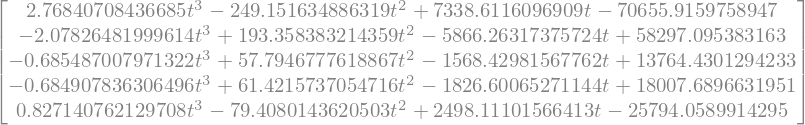

In [39]:
# Coerce results into desired format for printing
t = symbols('t')
wExpr = Matrix(np.zeros(n))
for i in range(n):
    for deg in range(k+1):
        #print(res[i,deg]*t**deg)
        wExpr[i] = wExpr[i] + res[i,deg]*t**deg

wExpr

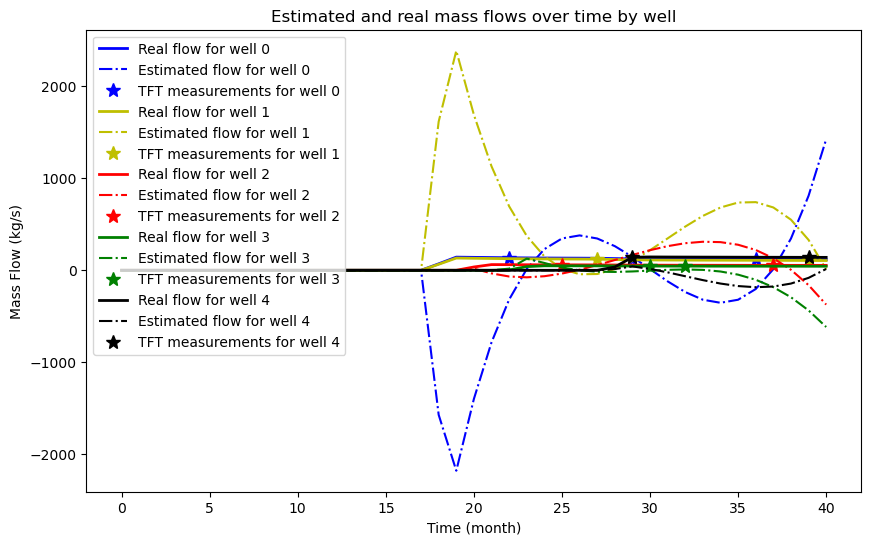

In [40]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
for i in range(n):
    plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dReal[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
            
plt.title("Estimated and real mass flows over time by well")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")
plt.legend()


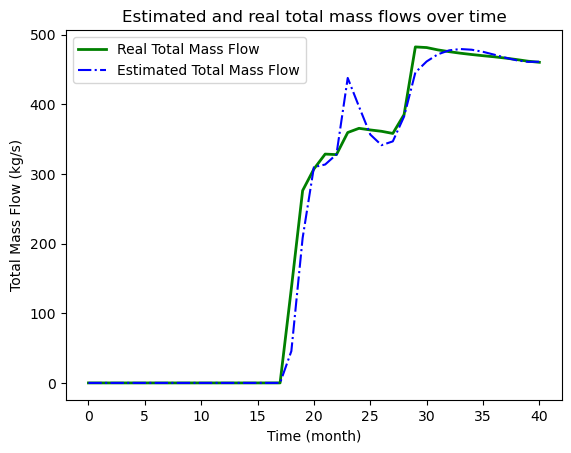

In [41]:
# Plot total flow vs found total flow
totalFlowFound = np.zeros((T,1))
times = range(T)
for time in range(T):
    tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
    #print(t, tff)
    totalFlowFound[time] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()

Bayesian model based on normal distribution of provided data. Bishop book